# Notebook for constructing age models for the Mamainse Point Volcanics

In [1]:
using Pkg
Pkg.activate("../")
Pkg.instantiate()
using Chron
using Plots, DelimitedFiles
using DataFrames, CSV
using Statistics, StatsBase

include("MCR_age_models.jl")

  Activating project at `~/Github/APWP_StratModels/code`


plot_posterior_paths (generic function with 1 method)

## Maminase Point Volcanics

- The bottom of the section is in the lowermost Alona Bay reversed polarity zone associated with the onset of Midcontinent Rift volcanism. This onset is not particularly well-dated with the best constraints coming from early rift intrusions such as the 1109.0±1.3 Ma Sunday Lake intrusion (Bleeker et al., 2020).
- We know that the first site of the lower normal polarity zone (the Flour Bay normal polarity zone) at stratigraphic height of 1351 m is younger than 1105.15±0.33 Ma which is the date of a rhyolite from Agate Point in the Osler Volcanic Group which is within the Alona Bay reversed polarity zone.
- The Flour Bay Tuff is dated to be 1100.36 $\pm$ 0.25 Ma which can be used as an absolute constraint at strat height of 1970 m.
- The top of the section is of normal polarity with no radiometric constraints. The youngest dated flow during the period of massive basaltic volcanism is the Greenstone Flow (1091.59 ± 0.27 Ma; Swanson-Hysell et al., 2019), let's set it to be 1091 $\pm$ 4 Ma to allow for many different scenarios of eruption rate at Mamainse Point.

In [2]:
Mamainse_Name = ("Oldest magmatism", "Max age on normal polarity", "Flour Bay tuff", "Top of Mamainse") # Et cetera
Mamainse_Age           = [ 1109, 1105.15,1100.36, 1090] # Measured ages
Mamainse_Age_sigma     = [ 1.3/2, 0.33/2, 0.25/2, 4/2] # Measured 1-σ uncertainties
Mamainse_Height        = [ 0.0, 1351,  1970,  4100] # Depths below surface should be negative
Mamainse_Age_Sidedness = [0, -1, 0, 0] # Sidedness (zeros by default: geochron constraints are two-sided). Use -1 for a maximum age and +1 for a minimum age, 0 for two-sided

Mamainse_Path = "../../data/age_models_output/Mamainse_Point_Volcanic_Group" # Where do you want output files to be stored

# construct the section (ChronAgeData object)
Mamainse_section = make_ChronAgeData(Mamainse_Name, Mamainse_Age, Mamainse_Age_sigma, Mamainse_Height, Mamainse_Age_Sidedness, Mamainse_Path, Age_Unit="Ma", Height_Unit="m")

ChronAgeData{4}(("Oldest magmatism", "Max age on normal polarity", "Flour Bay tuff", "Top of Mamainse"), [0.0, 1351.0, 1970.0, 4100.0], [0.01, 0.01, 0.01, 0.01], [1109.0, 1105.15, 1100.36, 1090.0], [0.65, 0.165, 0.125, 2.0], [NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN], [0.0, -1.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0], [#undef, #undef, #undef, #undef], (:Chronometer, :Chronometer, :Chronometer, :Chronometer), [NaN NaN NaN NaN; NaN NaN NaN NaN; … ; NaN NaN NaN NaN; NaN NaN NaN NaN], "../../data/age_models_output/Mamainse_Point_Volcanic_Group", 2, "Ma", "m", :cdf)

In [3]:
Mamainse_age_model_config, Mamainse_age_model_mdl, Mamainse_age_model_agedist, Mamainse_age_model_lldist = run_age_model(Mamainse_section, 10, 0.20, 1000, save_results=false, plot_results=false)

┌ Info: Generating stratigraphic age-depth model...
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:28
┌ Info: Burn-in: 575000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:626
Burn-in... 100%|█████████████████████████████████████████| Time: 0:00:00
┌ Info: Collecting sieved stationary distribution: 575000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:689
Collecting... 100%|██████████████████████████████████████| Time: 0:00:00


(StratAgeModelConfiguration(10.0, 575000, 1000, 575, 0.2), StratAgeModel([0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0  …  4010.0, 4020.0, 4030.0, 4040.0, 4050.0, 4060.0, 4070.0, 4080.0, 4090.0, 4100.0], [1108.9461643530096, 1108.898798556442, 1108.8517503840114, 1108.8005780807548, 1108.741807024959, 1108.6870180005126, 1108.6421133295091, 1108.6106705707418, 1108.5585029095666, 1108.5116877506907  …  1090.5646461947226, 1090.5163433445978, 1090.47120404664, 1090.4177306913282, 1090.361595357553, 1090.3105677321948, 1090.2571120725697, 1090.1987222636699, 1090.1535980038675, 1090.1098122165702], [0.603648119295573, 0.6448451515814001, 0.6803504730827704, 0.7085456953053954, 0.7685787715411807, 0.8031448614579283, 0.833949180690571, 0.8543565533074126, 0.8894242416441066, 0.9196895967220876  …  1.615078798023457, 1.5930558781330104, 1.5843513517858083, 1.581455716295496, 1.5724434758764638, 1.542860777288392, 1.533941140131176, 1.4941474820401632, 1.4763983730243195, 1.466

### posterior summary age model

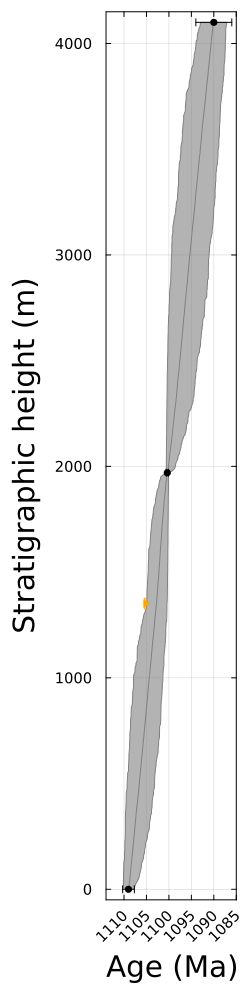

In [4]:
Mamainse_age_model = plot_age_model(Mamainse_section, Mamainse_age_model_mdl, save_figure=false)
plot!(ylim=(-50, 4150), xlim=(1085, 1114), legend=false, left_margin = 12Plots.mm, guidefontsize=20, size=(250, 1000))
savefig(Mamainse_age_model, Mamainse_section.Path*"_AgeDepthModel.pdf")
display(Mamainse_age_model)

### example posterior accumulation models

agemin: 1090.1098122165702, agemax: 1108.9461643530096, halfw: 0.25, Δt: 0.1
Number of windows: 184
  0.105210 seconds (9.00 k allocations: 10.437 MiB)


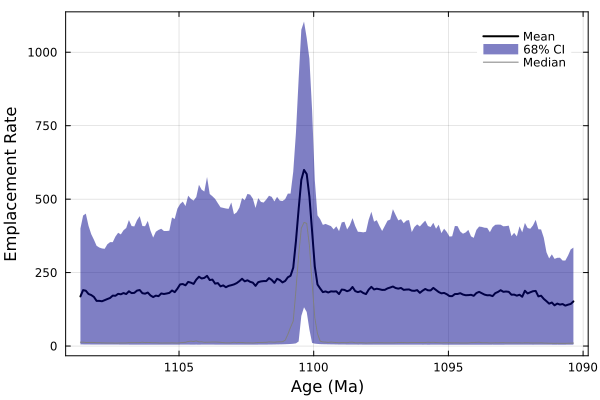

In [5]:
plot_accumulation_model(Mamainse_section, Mamainse_age_model_config, Mamainse_age_model_mdl, Mamainse_age_model_agedist, binwidth=0.5, stepfrac=0.2, save_figure=false)

### example posterior age models

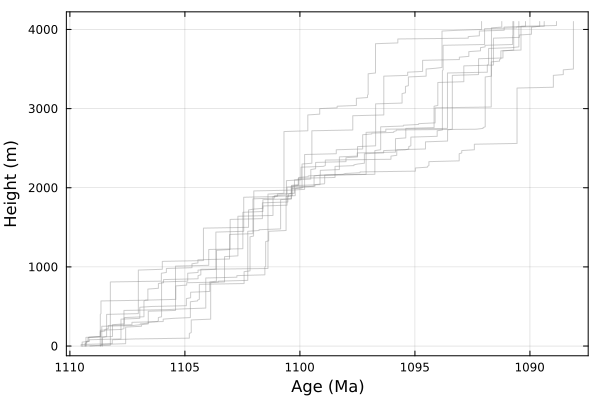

In [6]:
plot_posterior_paths(Mamainse_section, Mamainse_age_model_agedist, Mamainse_age_model_mdl)

## save the age models to a file

In [7]:
# use the mdl.height as index, agedist as the data
Mamainse_age_models_df = DataFrame(hcat(Mamainse_age_model_mdl.Height, Mamainse_age_model_agedist), :auto)
# rename the first three columns to be site, height
rename!(Mamainse_age_models_df, Dict(:x1 => "height"))
Mamainse_age_models_df

Row,height,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,⋯
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,0.0,1108.51,1108.61,1108.78,1109.16,1109.26,1108.44,1109.75,1108.88,1107.84,1108.73,1109.37,1108.48,1107.84,1108.88,1108.38,1108.47,1108.76,1109.24,1108.57,1108.71,1109.34,1109.71,1109.56,1108.95,1108.23,1108.32,1109.18,1108.24,1109.24,1108.49,1109.52,1108.64,1109.32,1108.72,1108.0,1109.7,1108.04,1108.87,1108.63,1108.29,1108.89,1108.98,1110.29,1108.72,1109.22,1109.14,1107.85,1109.69,1109.32,1109.07,1108.52,1109.91,1108.8,1108.21,1109.01,1108.29,1109.18,1107.99,1109.07,1108.74,1108.39,1107.77,1109.14,1107.87,1109.54,1109.71,1108.94,1108.92,1111.23,1109.76,1108.31,1108.91,1109.14,1108.81,1109.45,1109.81,1109.49,1108.78,1108.95,1108.99,1109.57,1109.3,1109.41,1108.55,1108.84,1109.7,1108.79,1108.59,1108.69,1108.51,1110.07,1108.53,1108.14,1109.33,1108.8,1108.79,1109.89,1109.34,1108.44,⋯
2,10.0,1108.51,1108.61,1108.78,1109.16,1108.17,1108.44,1109.75,1108.88,1107.84,1108.73,1109.37,1108.48,1107.84,1108.88,1108.38,1108.47,1108.76,1109.24,1108.57,1108.71,1109.34,1109.71,1109.56,1108.95,1108.23,1108.32,1109.18,1108.24,1109.24,1108.49,1109.52,1108.64,1109.32,1108.72,1108.0,1109.7,1108.04,1108.87,1108.63,1108.29,1108.89,1108.84,1110.29,1108.72,1109.22,1109.14,1107.85,1109.69,1108.78,1109.07,1108.52,1109.91,1108.8,1108.21,1109.01,1106.66,1109.18,1107.99,1109.07,1108.74,1108.39,1107.08,1109.14,1107.87,1109.54,1109.71,1108.94,1108.92,1111.23,1109.76,1108.31,1108.91,1109.14,1108.81,1109.45,1109.81,1109.49,1108.78,1108.95,1108.99,1109.57,1109.3,1109.41,1108.55,1108.19,1109.7,1108.79,1108.59,1108.69,1108.51,1109.34,1108.53,1108.14,1109.33,1108.8,1108.79,1109.89,1109.34,1108.44,⋯
3,20.0,1108.51,1108.61,1108.78,1109.16,1107.5,1108.44,1109.75,1108.88,1107.84,1108.73,1109.37,1108.48,1107.84,1108.88,1108.38,1108.47,1108.76,1109.24,1108.57,1108.71,1109.34,1109.71,1109.56,1108.95,1108.23,1108.32,1109.18,1108.24,1109.24,1108.49,1109.52,1108.64,1109.32,1108.72,1108.0,1109.7,1106.4,1108.87,1108.63,1108.29,1108.89,1108.84,1110.29,1108.72,1107.81,1109.14,1107.39,1109.69,1108.78,1109.07,1108.52,1109.91,1108.8,1108.21,1109.01,1106.66,1109.18,1107.14,1109.07,1108.74,1108.39,1106.77,1107.97,1107.87,1109.54,1109.71,1108.94,1108.45,1111.23,1109.76,1108.31,1108.91,1109.14,1108.81,1109.45,1109.81,1109.49,1108.75,1108.95,1108.99,1109.57,1109.3,1109.41,1108.55,1108.19,1109.7,1108.79,1108.59,1108.69,1108.51,1109.34,1108.23,1108.14,1109.33,1108.8,1108.79,1109.89,1109.34,1108.44,⋯
4,30.0,1108.51,1108.61,1108.78,1109.16,1107.5,1108.44,1109.75,1108.88,1107.84,1108.73,1109.33,1108.48,1107.84,1108.88,1108.38,1108.47,1108.76,1109.24,1108.57,1108.71,1109.34,1109.71,1109.56,1108.95,1108.23,1108.32,1109.18,1108.24,1109.24,1108.49,1109.52,1108.43,1109.32,1108.72,1108.0,1109.7,1106.09,1108.87,1108.51,1108.29,1108.89,1108.84,1110.29,1108.72,1107.81,1109.14,1107.39,1109.69,1108.78,1109.07,1108.52,1

In [8]:
# write the DataFrame to a csv file
CSV.write(Mamainse_section.Path*"_posterior_ages.csv", Mamainse_age_models_df)

"../../data/age_models_output/Mamainse_Point_Volcanic_Group_posterior_ages.csv"